In [14]:
# Step 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [15]:
# Step 3: Load dataset
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
df.shape

(891, 12)

In [17]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [18]:
# Step 4: Understand Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
# Step 5: Data Preprocessing
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [20]:
# Step 5: Data Preprocessing
# 5.1 Handle Missing Values
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = df.drop("Cabin", axis=1)

In [21]:
# Step 5.2: Encode categorical data
df["Sex"] = LabelEncoder().fit_transform(df["Sex"])

df["Embarked"] = LabelEncoder().fit_transform(df["Embarked"])

In [22]:
# Step 5.3: Feature selection

X = df[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch", "Embarked"]]
y = df["Survived"]

In [23]:
# Step 6: Split data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# Step 7: Train Model 1 - Naive Bayes

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [25]:
# Train model on training data

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [26]:
# Step 8: Predictions

nb_pred = nb_model.predict(X_test)
dt_pred = dt_model.predict(X_test)

In [28]:
# Step 9: Evaluation function

def evaluate_model(model_name, y_test, y_pred):
    print("Model:", model_name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [29]:
# Evaluate Naive Bayes
evaluate_model("Naive Bayes", y_test, nb_pred)

Model: Naive Bayes
Accuracy: 0.776536312849162
Precision: 0.7125
Recall: 0.7702702702702703
F1 Score: 0.7402597402597403
Confusion Matrix:
[[82 23]
 [17 57]]


In [30]:
# Evaluate Decision Tree
evaluate_model("Decision Tree", y_test, dt_pred)

Model: Decision Tree
Accuracy: 0.7821229050279329
Precision: 0.7272727272727273
Recall: 0.7567567567567568
F1 Score: 0.7417218543046358
Confusion Matrix:
[[84 21]
 [18 56]]


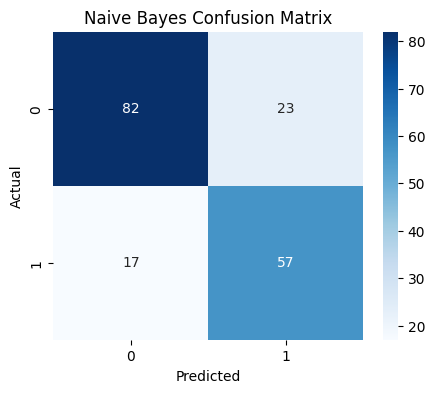

In [31]:
# Step 10: Confusion Matrix Heatmap - Naive Bayes

cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

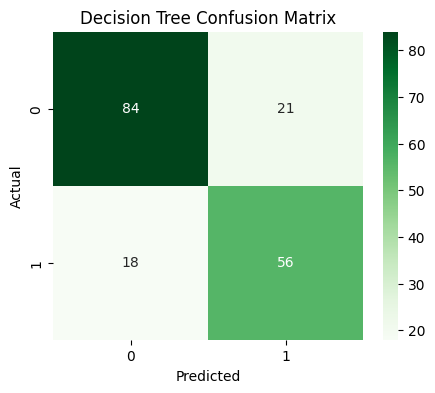

In [32]:
# Confusion Matrix Heatmap - Decision Tree

cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()